## Office-Home OOD Dataset

In [26]:
import pandas as pd
import json
from tabulate import tabulate

df = pd.read_csv('/home/sunaybhat/results_PureGen_PoisonDefense/From_Scratch/Narcissus/Results.csv')
df['Defense'] = df['Args'].apply(lambda x: json.loads(x)['baseline_defense'] if 'baseline_defense' in x else 'None')
df.loc[df['Data Key'] != 'Baseline', 'Defense'] = df['Data Key'].apply(lambda x: x[0:3] + '_' + x.split('[')[1].split('_')[0] if x != 'Baseline' else 'Baseline')


defense_rename = {
    'None': 'None',
    'EBM_cifar10': 'PureEBM',
    'EBM_officehome': 'PureEBM_OfficeHome',
}

results = []

for defense in ['None', 'EBM_cifar10', 'EBM_officehome']:
    df_defense = df[df['Defense'] == defense]

    poison_success = f'{df_defense["P1 Acc"].mean() * 100:.2f} \u00B1 {df_defense["P1 Acc"].std() * 100:.1f}'
    nat_acc = f'{df_defense["End Acc"].mean() * 100:.2f} \u00B1 {df_defense["End Acc"].std() * 100:.1f}'

    max_poison = f'{df_defense["P1 Acc"].max() * 100:.2f}'
    # print(f'Total Targets for {defense}: {df_defense.shape[0]}')
    

    results.append({
        'Defense': defense_rename[defense],
        'Poison Success (%)': poison_success,
        'Nat Acc (%)': nat_acc,
        'Max Poison (%)': max_poison,
    })

    if defense == 'None':
        results.append({
            'Defense': 'EPIc',
            'Poison Success (%)': '27.31 \u00B1 34.0',
            'Nat Acc (%)': '82.20 \u00B1 1.1',
            'Max Poison (%)': '84.71',
        })
        results.append({
            'Defense': 'FrieNDs',
            'Poison Success (%)': '8.32 \u00B1 22.3' ,
            'Nat Acc (%)': '91.01 \u00B1 0.4',
            'Max Poison (%)': '83.03',
        })


results_df = pd.DataFrame(results)

print(tabulate(results_df, headers='keys', tablefmt='pipe',showindex=True))

|    | Defense            | Poison Success (%)   | Nat Acc (%)   |   Max Poison (%) |
|---:|:-------------------|:---------------------|:--------------|-----------------:|
|  0 | None               | 37.48 ± 36.4         | 93.49 ± 0.2   |            90.49 |
|  1 | EPIc               | 27.31 ± 34.0         | 82.20 ± 1.1   |            84.71 |
|  2 | FrieNDs            | 8.32 ± 22.3          | 91.01 ± 0.4   |            83.03 |
|  3 | PureEBM            | 1.42 ± 0.8           | 91.44 ± 0.2   |             2.59 |
|  4 | PureEBM_OfficeHome | 1.44 ± 0.8           | 91.24 ± 0.2   |             2.63 |


## ResNet 18 HLB TinyIN GM

In [2]:
import pandas as pd
import json
from tabulate import tabulate


df = pd.read_csv('/home/sunaybhat/results_PureDefense/From_Scratch/GradientMatching/Results.csv')
df['Defense'] = df['Args'].apply(lambda x: json.loads(x)['baseline_defense'] if 'baseline_defense' in x else 'None')
df.loc[df['Data Key'] != 'Baseline', 'Defense'] = df['Data Key'].apply(lambda x: x[0:3])

defense_rename = {
    'None': 'None',
    'Epic': 'EPIc',
    'Friendly': 'FrieNDs',
    'EBM': 'PureEBM'
}

results = []

for defense in ['None', 'Epic', 'Friendly','EBM']:
    df_defense = df[df['Defense'] == defense]

    poison_success = df_defense["Success"].mean() * 100
    nat_acc = df_defense["End Acc"].mean()
    nat_acc_std = df_defense["End Acc"].std()
    # train_time = df_defense["Train Time"].mean() / 60  # convert to minutes

    total_targets = len(df_defense["Target Index"].unique())
    print(f'Total Targets for {defense}: {total_targets}')

    results.append({
        'Defense': defense_rename[defense],
        'Poison Success (%)': f'{poison_success:.2f}',
        'Nat Acc (Top-1) (%)': f'{nat_acc*100:.2f} \u00B1 {nat_acc_std*100:.2f}',
        # 'Mean Train Time (mins)': train_time
    })

results_df = pd.DataFrame(results)

print(tabulate(results_df, headers='keys', tablefmt='pipe',showindex=True))

Total Targets for None: 100
Total Targets for Epic: 100
Total Targets for Friendly: 92
Total Targets for EBM: 100
|    | Defense   |   Poison Success (%) | Nat Acc (Top-1) (%)   |
|---:|:----------|---------------------:|:----------------------|
|  0 | None      |                19    | 64.98 ± 0.24          |
|  1 | EPIc      |                12    | 59.85 ± 0.35          |
|  2 | FrieNDs   |                 3.26 | 32.91 ± 4.98          |
|  3 | PureEBM   |                 4    | 63.61 ± 0.27          |


In [ ]:
df_defense = df[df['Defense'] == 'Friendly']

# What Target Index are missing from 0-99
missing_targets = set(range(100)) - set(df_defense["Target Index"].unique())
print(f'Missing Targets: {missing_targets}')

# NGT Attack

In [20]:
def extract_steps(x):
    try:
        return int(x.split('Steps[')[1].split(']')[0])
    except Exception:
        return 0

def extract_jpeg(x):
    try:
        return int(x.split('_compressed')[1])
    except Exception:
        return 0

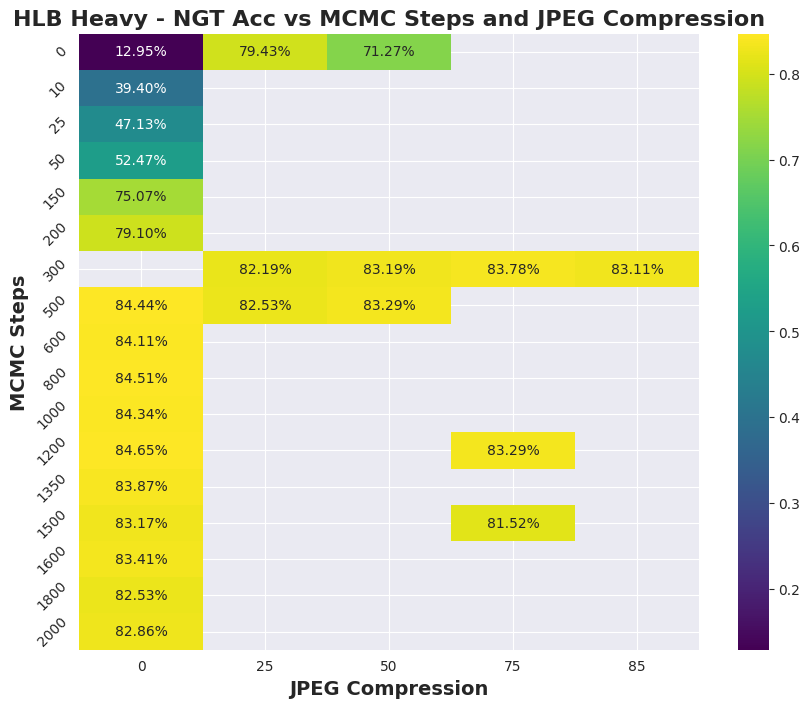

In [27]:
MODEL = 'HLB'

import pandas as pd
import json
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
pd.options.mode.chained_assignment = None

df = pd.read_csv('/home/sunaybhat/results_PureGen_PoisonDefense/NGT/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
args_df = pd.json_normalize(df['Args'])
df = pd.concat([df.drop(columns=['Args']), args_df], axis=1)

if MODEL == 'R18_HLB':
    df_filt = df[(df['Model'] == 'ResNet18_HLB')]
else:
    df_filt = df[(df['Model'] == 'HLB') & (df['hlb_type'] == 'large')]

df_filt['MCMC Steps'] = df_filt['data_key'].apply(lambda x: extract_steps(x))
df_filt['JPEG Compression'] = df_filt['data_key'].apply(lambda x: extract_jpeg(x))

# Pivot on MCMC Steps and JPEG Compression and take mean of End Acc
pivot_df = df_filt.pivot_table(index='MCMC Steps', columns='JPEG Compression', values='End Acc', aggfunc='mean')

# Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".2%", cmap='viridis')
if MODEL == 'R18_HLB':
    plt.title('ResNet18_HLB - NGT Acc vs MCMC Steps and JPEG Compression', fontsize=16, fontweight='bold')
else:
    plt.title('HLB Heavy - NGT Acc vs MCMC Steps and JPEG Compression', fontsize=16, fontweight='bold')

plt.xlabel('JPEG Compression', fontsize=14, fontweight='bold')
plt.ylabel('MCMC Steps', fontsize=14, fontweight='bold')
# plt.savefig('NGT_heatmap.png')

# Rorate x axis labels
plt.yticks(rotation=45);

In [22]:
pivot_df

JPEG Compression,0,25,50,75,85
MCMC Steps,,,,,
0,0.121271,0.7512,0.6739,0.57360,0.4950
150,0.716150,0.7758,0.7635,0.75580,0.7637
300,0.801200,0.7876,0.7957,0.80020,0.8061
500,0.815050,0.7927,0.8134,0.81260,0.8188
600,0.822300,0.7966,0.8105,0.81825,0.8232
750,NaN,0.7933,0.8043,0.81550,0.8214
1500,NaN,0.7901,0.7980,0.81060,NaN
